In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [10]:
!pip install gensim
import gensim
import re # Regular Expression Library
import string
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.stem.porter import PorterStemmer
from gensim.parsing.preprocessing import remove_stopwords
from nltk.tokenize import word_tokenize # Tokenizaion
from spacy.lang.en import English
from spacy.lang.en.stop_words import STOP_WORDS

In [11]:
# Plotting libraries
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# sklearn :
import sklearn
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import BernoulliNB
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.tree import DecisionTreeClassifier # Import Decision Tree Classifier
from sklearn.model_selection import train_test_split # Import train_test_split function
from sklearn import metrics #Import scikit-learn metrics module for accuracy calculation
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import roc_curve, auc

from google.colab import drive

# This will prompt you to authorize access to your Google Drive
drive.mount('/content/drive')

Mounted at /content/drive


In [12]:
# load the dataset
# print the dataset
df = pd.read_csv('/content/drive/My Drive/AI PROJECT Y2S2/Review.csv')
df.head(100)

,Company,Model,Year,Reviewer,Date,Title,Rating,Review
0,acura,ilx,2013,mahowald,08/12/2012,Getting 43 Mpg on daily commute,5,"I love this car.\nGas mileage, suspension, and..."
1,acura,ilx,2013,VIP,07/26/2016,New to me ILX,5,I purchased my 2013 ILX from the dealer used w...
2,acura,ilx,2013,bybchucky,09/14/2013,Excellet Commuter Car,4,I recently purchased a 2013 ILX with the Tech ...
3,acura,ilx,2013,bayareamom,01/26/2015,Peppy Hybrid that Turns Heads,4,We bought our ILX used and have been incredibl...
4,acura,ilx,2013,Kerry Olson,03/26/2016,2013 Acura ILX Hybrid w/ Tech Package,5,In April of 2015 we were in need of another ca...
...,...,...,...,...,...,...,...,...
95,acura,ilx,2018,Fred,09/20/2018,Very good car for the money,4,I always admired this car when I saw it drivin...
96,acura,ilx,2018,Graham,05/03/2019,Love/Hate,5,Last June 2019 I sold my ILX lease to Carvana ...
97,acura,ilx,2018,john,08/31/2018,smaller is better,4,I had been driving an Acura TL and then TLX's ...
98,acura,ilx,2018,Nicole,12/04/2018,Acura ILX 2018 MAJOR ISSUES,5,"This is my third ILX because I LOVE this car, ..."


In [13]:
# diaplay the column name of our dataset
df.columns

Index(['Company', 'Model', 'Year', 'Reviewer', 'Date', 'Title', 'Rating',
       'Review'],
      dtype='object')

In [14]:
# information about the data set
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 299045 entries, 0 to 299044
Data columns (total 8 columns):
 #   Column    Non-Null Count   Dtype 
---  ------    --------------   ----- 
 0   Company   299045 non-null  object
 1   Model     299045 non-null  object
 2   Year      299045 non-null  int64 
 3   Reviewer  298938 non-null  object
 4   Date      299028 non-null  object
 5   Title     299010 non-null  object
 6   Rating    299045 non-null  int64 
 7   Review    299040 non-null  object
dtypes: int64(2), object(6)
memory usage: 18.3+ MB


,Year,Rating
count,299045.000000,299045.000000
mean,2007.492247,3.980886
std,5.330847,0.993001
min,2000.000000,0.000000
25%,2003.000000,4.000000
50%,2006.000000,4.000000
75%,2011.000000,5.000000
max,2020.000000,5.000000


In [15]:
df.isnull().sum()

,0
Company,0
Model,0
Year,0
Reviewer,107
Date,17
Title,35
Rating,0
Review,5


In [16]:
# Row an column in the dataset
print(f"Number of rows: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")

Number of rows: 299045
Number of columns: 8


In [17]:
df = df.drop([ 'Reviewer', 'Date', 'Title'], axis=1)

In [18]:
df.head(100)

,Company,Model,Year,Rating,Review
0,acura,ilx,2013,5,"I love this car.\nGas mileage, suspension, and..."
1,acura,ilx,2013,5,I purchased my 2013 ILX from the dealer used w...
2,acura,ilx,2013,4,I recently purchased a 2013 ILX with the Tech ...
3,acura,ilx,2013,4,We bought our ILX used and have been incredibl...
4,acura,ilx,2013,5,In April of 2015 we were in need of another ca...
...,...,...,...,...,...
95,acura,ilx,2018,4,I always admired this car when I saw it drivin...
96,acura,ilx,2018,5,Last June 2019 I sold my ILX lease to Carvana ...
97,acura,ilx,2018,4,I had been driving an Acura TL and then TLX's ...
98,acura,ilx,2018,5,"This is my third ILX because I LOVE this car, ..."


In [19]:
# Check for duplicate rows in the entire dataset
duplicate_count = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_count}")

# Display a few duplicates if they exist
if duplicate_count > 0:
    display(df[df.duplicated()].head())

Number of duplicate rows: 807


,Company,Model,Year,Rating,Review
383,acura,mdx,2002,4,I have fallen in love with a car/ suv. \nSo fa...
1403,acura,mdx,2008,5,This is our 2nd MDX. Poor mileage is because ...
1550,acura,mdx,2010,5,This was my first Acura. I switch from a Volvo...
1742,acura,mdx,2014,5,I totaled my 2009 Acura MDX but the safety fea...
1903,acura,mdx,2016,5,


In [20]:
# Remove duplicate rows
df = df.drop_duplicates()
print(f"Duplicates removed. New dataset shape: {df.shape}")

Duplicates removed. New dataset shape: (298238, 5)


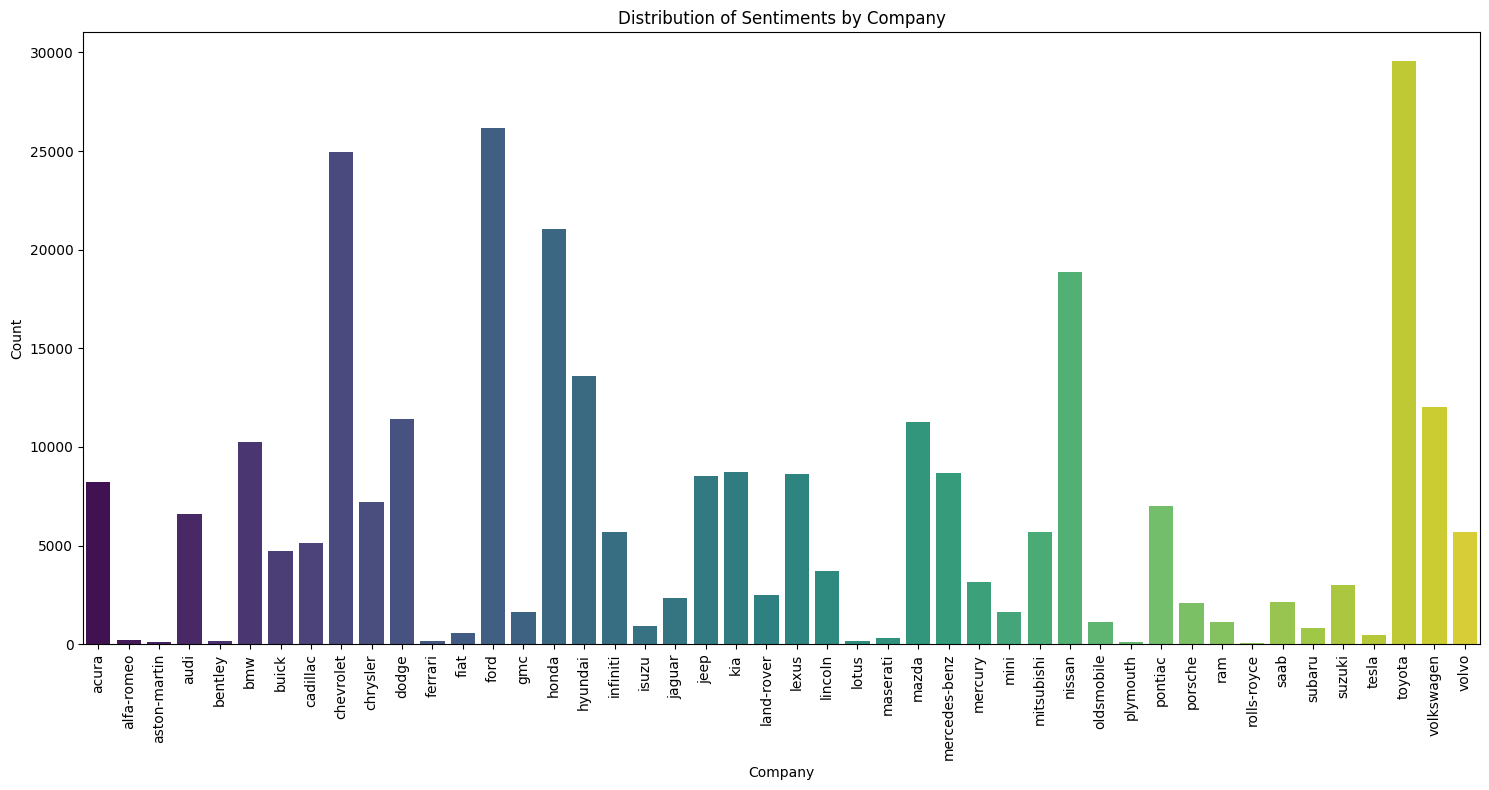

In [21]:
plt.figure(figsize=(15, 8))
sns.countplot(x='Company', data=df, palette='viridis')
plt.title('Distribution of Sentiments by Company')
plt.xlabel('Company')
plt.ylabel('Count')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [22]:
num_companies = df['Company'].nunique()
print(f"There are {num_companies} unique companies in the dataset.")

There are 46 unique companies in the dataset.


In [23]:
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [24]:
def convert_sentiment(rating):
    if rating <= 3:
        return 0  # Negative
    elif rating == 4:
        return 1  # Neutral
    else:
        return 2  # Positive

df['Sentiment'] = df['Rating'].apply(convert_sentiment)
print("Target distribution:")
display(df['Sentiment'].value_counts())
display(df.head())

Target distribution:


,count
Sentiment,
1,144364
2,93645
0,60229


,Company,Model,Year,Rating,Review,Sentiment
0,acura,ilx,2013,5,"I love this car.\nGas mileage, suspension, and...",2
1,acura,ilx,2013,5,I purchased my 2013 ILX from the dealer used w...,2
2,acura,ilx,2013,4,I recently purchased a 2013 ILX with the Tech ...,1
3,acura,ilx,2013,4,We bought our ILX used and have been incredibl...,1
4,acura,ilx,2013,5,In April of 2015 we were in need of another ca...,2


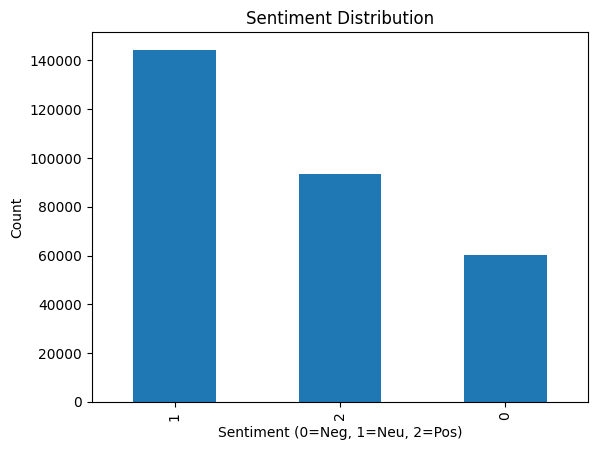

In [25]:
import matplotlib.pyplot as plt

# Count values
sentiment_counts = df['Sentiment'].value_counts()

# Plot
plt.figure()
sentiment_counts.plot(kind='bar')

plt.title("Sentiment Distribution")
plt.xlabel("Sentiment (0=Neg, 1=Neu, 2=Pos)")
plt.ylabel("Count")

plt.show()

In [26]:
# 3. Data Cleaning
df = df[['Review', 'Rating']].dropna()

* Removal of Mentions:

In social media, Mentions are used to call/mention another user into our post. Generally, mentions don't have an added value to our model. So we will remove them.

A mention has a special pattern: **@UserName,** So we will remove all string which starts with @

In [27]:
# Removal of Mentions:

## Creating a fucntion that will be applied to our datset :
def RemoveMentions(Review):
    text_ = re.sub(r"@\S+", "", Review)
    return text_


## Applying the function to each row of the data
print("=========== Before Removing Mentions ============\n")
print("\t" + df.loc[5, "Review"])
print("\n=========== After Removing Mentions ===========\n")
df["Review"] = df["Review"].apply(RemoveMentions)
print("\t" + df.loc[5, "Review"])

=========== Before Removing Mentions ============

	Just upgraded from my 5-spd Saab 9-3 sedan to a brand new Acura ilx w/premium package and the 2.4L 6-spd engine.
The premium package comes with nearly everything that you could ask for minus navigation.

Very nice engine note that gives the car some personality without sounding like a cheap tuner.
The only knock I could say about the ilx is the interior space which is expected to be small due to the price point and market that Acura intends to target.

If you're in your 20s or early 30s and are looking for something fun to drive without sacrificing the luxury amenities, look no further than the ilx.

Oh and by the way, I'm getting 35-40 highway mpg.

=========== After Removing Mentions ===========

	Just upgraded from my 5-spd Saab 9-3 sedan to a brand new Acura ilx w/premium package and the 2.4L 6-spd engine.
The premium package comes with nearly everything that you could ask for minus navigation.

Very nice engine note that gives th

In [28]:
# Defining a list containing punctuation signs of english :
punctuations_list = string.punctuation


## Defining that will be applied to our datset :
def RemovePunctuations(Review):
    transformator = str.maketrans('', '', punctuations_list)
    return Review.translate(transformator)


## Applying the fucntion to all rows :
print("=========== Before Removing Punctuations =============\n")
print("\t" + df.loc[10, "Review"])
print("\n=========== After Removing Punctuations \===========\n")
df["Review"] = df["Review"].apply(RemovePunctuations)
print("\t" + df.loc[10, "Review"])

=========== Before Removing Punctuations =============

	Grown up with a 6 speed. Smooth shifting tranny. Soft touches allover. Smart phone integration is incredible. 

=========== After Removing Punctuations \===========

	Grown up with a 6 speed Smooth shifting tranny Soft touches allover Smart phone integration is incredible 


In [29]:
df.loc[10, "Review"]

'Grown up with a 6 speed Smooth shifting tranny Soft touches allover Smart phone integration is incredible '

In [30]:
# Getting the pre defined stop words from nltk library :
stopwords = stopwords.words('english')

## Copying the df to use other libraries (spacy and gensim)
df_copy1 = df.loc[:100].copy(deep=True)
df_copy2 = df.copy(deep=True)  # deep copy to create another df

## Applying the fucntion to all rows
print("=========== Before Removing Stop words ============\n")
print("\t" + df_copy2.loc[12, "Review"])
print("\n=========== After Removing Stop words ===========\n")

## Exclude stopwords with Python's list comprehension and pandas.DataFrame.apply.
df_copy2['Review'] = df_copy2['Review'].apply(lambda x: ' '.join([word for word in x.split() if word not in (stopwords)]))
print("\t" + df_copy2.loc[12, "Review"])

=========== Before Removing Stop words ============

	The Ilx is a great car I am a HondaAcura fan which is a big part of why I purchased this car
You can get more car for the money with Toyota Honda or Nissan any day but if you want the Acura badge and build quality you pay the premium The car handles extremely well road noise is pretty low and the interior is one of the most comfortable and aesthetically appealing of any car I have owned The interior isnt large but its done very well I really enjoy driving this car and it gets its fair share of looks Dont judge this car by pictures I went to the dealer to buy a tsx and left with this because when I saw it the body styling really hooked me in It is definitely not a rebadged civic

=========== After Removing Stop words ===========

	The Ilx great car I HondaAcura fan big part I purchased car You get car money Toyota Honda Nissan day want Acura badge build quality pay premium The car handles extremely well road noise pretty low interior

In [31]:
df.loc[5, "Review"]

'Just upgraded from my 5spd Saab 93 sedan to a brand new Acura ilx wpremium package and the 24L 6spd engine\nThe premium package comes with nearly everything that you could ask for minus navigation\n\nVery nice engine note that gives the car some personality without sounding like a cheap tuner\nThe only knock I could say about the ilx is the interior space which is expected to be small due to the price point and market that Acura intends to target\n\nIf youre in your 20s or early 30s and are looking for something fun to drive without sacrificing the luxury amenities look no further than the ilx\n\nOh and by the way Im getting 3540 highway mpg'

In [32]:
## Creating a fucntion that will be applied to our datset :
def RemoveStopsSpacy(Review):
    # Load English tokenizer, tagger, parser, NER and word vectors
    nlp = English()

    #  "nlp" Object is used to create documents with linguistic annotations.
    my_doc = nlp(Review)

    # Create list of word tokens
    token_list = []
    for token in my_doc:
        token_list.append(token.text)
    # Create list of word tokens after removing stopwords
    filtered_sentence = []

    for word in token_list:
        lexeme = nlp.vocab[word]
        if lexeme.is_stop == False:
            filtered_sentence.append(word)
    return filtered_sentence


## Applying the fucntion to all rows
print("=========== Before Removing Stop words with spaCy ===========\n")
print("\t" + df_copy1.loc[12, "Review"])
print("\n=========== After Removing Stop words with spaCy ===========\n")

## Exclude stopwords with Python's list comprehension and pandas.DataFrame.apply.
df_copy1['Review'] = df_copy1['Review'].apply(lambda x: ' '.join(RemoveStopsSpacy(x)))
print("\t" + df_copy1.loc[12, "Review"])

=========== Before Removing Stop words with spaCy ===========

	The Ilx is a great car I am a HondaAcura fan which is a big part of why I purchased this car
You can get more car for the money with Toyota Honda or Nissan any day but if you want the Acura badge and build quality you pay the premium The car handles extremely well road noise is pretty low and the interior is one of the most comfortable and aesthetically appealing of any car I have owned The interior isnt large but its done very well I really enjoy driving this car and it gets its fair share of looks Dont judge this car by pictures I went to the dealer to buy a tsx and left with this because when I saw it the body styling really hooked me in It is definitely not a rebadged civic

=========== After Removing Stop words with spaCy ===========

	Ilx great car HondaAcura fan big purchased car 
 car money Toyota Honda Nissan day want Acura badge build quality pay premium car handles extremely road noise pretty low interior comfor

In [33]:
df.loc[8]

,8
Review,My previous car was a leased 2015 Civic EXL bu...
Rating,5


In [34]:
## Applying the fucntion to all rows
print("=========== Before Removing Stop words with Gensim =======\n")
print("\t" + df.loc[12, "Review"])
print("\n=========== After Removing Stop words with Gensim =======\n")
df['Review'] = df['Review'].apply(lambda x: gensim.parsing.preprocessing.remove_stopwords(x))
print("\t" + df.loc[12, "Review"])

=========== Before Removing Stop words with Gensim =======

	The Ilx is a great car I am a HondaAcura fan which is a big part of why I purchased this car
You can get more car for the money with Toyota Honda or Nissan any day but if you want the Acura badge and build quality you pay the premium The car handles extremely well road noise is pretty low and the interior is one of the most comfortable and aesthetically appealing of any car I have owned The interior isnt large but its done very well I really enjoy driving this car and it gets its fair share of looks Dont judge this car by pictures I went to the dealer to buy a tsx and left with this because when I saw it the body styling really hooked me in It is definitely not a rebadged civic

=========== After Removing Stop words with Gensim =======

	The Ilx great car I HondaAcura fan big I purchased car You car money Toyota Honda Nissan day want Acura badge build quality pay premium The car handles extremely road noise pretty low interio

In [35]:
## Creating a fucntion that will be applied to our datset :
def RemoveLinks(Review):
    return re.sub(r"http\S+", "", Review)

## Applying the fucntion to all rows of our dataset :
print("====== Before Removing Hyperlinks =====\n")
print("\t" + df.loc[0, "Review"])  # let's see for example the first row, which contains an hyperlink.
print("\n====== After Removing Hyperlinks ====\n")
df['Review'] = df['Review'].apply(RemoveLinks)
print("\t" + df.loc[0, "Review"])

====== Before Removing Hyperlinks =====

	I love car Gas mileage suspension stereo great Bluetooth integration Pandora integration work perfectly Suspension noise cancellation work amazingly Although looks small plenty room big Gas mileage 42 45 trying

====== After Removing Hyperlinks ====

	I love car Gas mileage suspension stereo great Bluetooth integration Pandora integration work perfectly Suspension noise cancellation work amazingly Although looks small plenty room big Gas mileage 42 45 trying


In [36]:
## Creating a fucntion that will be applied to our datset :
def RemoveNumbers(Review):
    return re.sub(r"[0-9]+", "", Review)

## Applying the fucntion to all rows
print("=========== Before Removing Numbers =======\n")
print("\t" + df.loc[2,"Review"])  #let's see for example the thirs row, which contains an number 50
print("\n=========== After Removing Numbers ========\n")
df['Review'] = df['Review'].apply(RemoveNumbers)
print("\t" + df.loc[2,"Review"])

=========== Before Removing Numbers =======

	I recently purchased 2013 ILX Tech pkg I pleased I 2008 Acura TL prior purchasing car I thought I miss V6 acceleration I honestly dont A lot reviews 150 hp underpowered I car adequate In fact picks nicely highway I dont trouble passing cars The interior nice built feels lot wider outside appearance believe The rear leg room excellent considering compact car As stated excellent commuter car

=========== After Removing Numbers ========

	I recently purchased  ILX Tech pkg I pleased I  Acura TL prior purchasing car I thought I miss V acceleration I honestly dont A lot reviews  hp underpowered I car adequate In fact picks nicely highway I dont trouble passing cars The interior nice built feels lot wider outside appearance believe The rear leg room excellent considering compact car As stated excellent commuter car


In [37]:
## Creating a fucntion that will be applied to our datset :
def RemoveWhitespaces(Review):
    Review = Review.strip()  # Leading and trailing whitespaces are removed
    return re.sub(r" +"," ",Review)

## Applying the fucntion to all rows :
df['Review'] = df['Review'].apply(lambda x: RemoveWhitespaces(x))

In [38]:
# And now, let's see our tweet content feature:
print("The number of unique values of the text feature is {}".format(df['Review'].nunique()))
print("The total number of rows in our dataframe is : {}".format(len(df)))
print("The number of duplicated rows in our dataframe is : {}".format(len(df)-df['Review'].nunique()))

The number of unique values of the text feature is 295602
The total number of rows in our dataframe is : 298233
The number of duplicated rows in our dataframe is : 2631


In [39]:
# Removing duplicate row records but keeping original text : ( we only keep the first duplicate )
df = df.drop_duplicates(subset='Review', keep='first')

In [40]:
# Checking if duplicates have been removed:
print("The number of unique values of the text feature is {}".format(df['Review'].nunique()))
print("The total number of rows in our dataframe is : {}".format(len(df)))
print("The number of duplicated rows in our dataframe is : {}".format(len(df)-df['Review'].nunique()))

The number of unique values of the text feature is 295602
The total number of rows in our dataframe is : 295602
The number of duplicated rows in our dataframe is : 0


In [41]:
# NLTK (Natural Language Toolkit) provides a utility function for tokenizing data.
df['tokenized_Review'] = df['Review'].apply(word_tokenize)

# Remove the old 'tokenized_tweets' column if it exists to clean up the output
if 'tokenized_tweets' in df.columns:
    df.drop(columns=['tokenized_tweets'], inplace=True)

df.head()

,Review,Rating,tokenized_Review
0,I love car Gas mileage suspension stereo great...,5,"[I, love, car, Gas, mileage, suspension, stere..."
1,I purchased ILX dealer k miles So far good I H...,5,"[I, purchased, ILX, dealer, k, miles, So, far,..."
2,I recently purchased ILX Tech pkg I pleased I ...,4,"[I, recently, purchased, ILX, Tech, pkg, I, pl..."
3,We bought ILX incredibly pleased far As Prius ...,4,"[We, bought, ILX, incredibly, pleased, far, As..."
4,In April need car Initially I looked BMW Infin...,5,"[In, April, need, car, Initially, I, looked, B..."


In [42]:
# Creating an instance of the stemmer :
stemmer = PorterStemmer()

## Creating a fucntion that will be applied to our datset :
def Stemmer(Review):
    return " ".join([stemmer.stem(word) for word in Review])

## Applying the fucntion to all rows :
df['tokenized_Review_stemmed'] = df['tokenized_Review'].apply(lambda Review: Stemmer(Review))

In [43]:
import nltk
nltk.download('wordnet')

# Creating an instance of the limmatizer :
wordnet_lemmatizer = WordNetLemmatizer()

# Applying the limmatizer to all rows:
df['tokenized_Review_stemmed_lemmatized'] = df['tokenized_Review_stemmed'].apply(
    lambda text: wordnet_lemmatizer.lemmatize(text, pos="v"))

[nltk_data] Downloading package wordnet to /root/nltk_data...


In [44]:
df.head(50)

,Review,Rating,tokenized_Review,tokenized_Review_stemmed,tokenized_Review_stemmed_lemmatized
0,I love car Gas mileage suspension stereo great...,5,"[I, love, car, Gas, mileage, suspension, stere...",i love car ga mileag suspens stereo great blue...,i love car ga mileag suspens stereo great blue...
1,I purchased ILX dealer k miles So far good I H...,5,"[I, purchased, ILX, dealer, k, miles, So, far,...",i purchas ilx dealer k mile so far good i hond...,i purchas ilx dealer k mile so far good i hond...
2,I recently purchased ILX Tech pkg I pleased I ...,4,"[I, recently, purchased, ILX, Tech, pkg, I, pl...",i recent purchas ilx tech pkg i pleas i acura ...,i recent purchas ilx tech pkg i pleas i acura ...
3,We bought ILX incredibly pleased far As Prius ...,4,"[We, bought, ILX, incredibly, pleased, far, As...",we bought ilx incred pleas far as priu owner i...,we bought ilx incred pleas far as priu owner i...
4,In April need car Initially I looked BMW Infin...,5,"[In, April, need, car, Initially, I, looked, B...",in april need car initi i look bmw infint g co...,in april need car initi i look bmw infint g co...
5,Just upgraded spd Saab sedan brand new Acura i...,4,"[Just, upgraded, spd, Saab, sedan, brand, new,...",just upgrad spd saab sedan brand new acura ilx...,just upgrad spd saab sedan brand new acura ilx...
6,I ILX month miles It excellent car The complai...,5,"[I, ILX, month, miles, It, excellent, car, The...",i ilx month mile it excel car the complaint l ...,i ilx month mile it excel car the complaint l ...
7,Have trouble maintenance years Ive oil tires c...,5,"[Have, trouble, maintenance, years, Ive, oil, ...",have troubl mainten year ive oil tire chang it...,have troubl mainten year ive oil tire chang it...
8,My previous car leased Civic EXL job change I ...,5,"[My, previous, car, leased, Civic, EXL, job, c...",my previou car leas civic exl job chang i need...,my previou car leas civic exl job chang i need...
9,This second month I driving car work everyday ...,4,"[This, second, month, I, driving, car, work, e...",thi second month i drive car work everyday mil...,thi second month i drive car work everyday mil...


In [45]:
from google.colab import files

# Save the preprocessed dataframe to a CSV
output_filename = 'preprocessed_car_reviews.csv'
df.to_csv(output_filename, index=False)

# Trigger the download to your local machine
files.download(output_filename)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [46]:
# Let's create a function which creates a wordcloud of a given pandas Series object :
def wordCloud(data_pos, max_words):
    # call the wordcloud function to show the most top 1000 used words:
    cloud = WordCloud(max_words=max_words, background_color="white", width=1600, height=800,
                      collocations=False).generate(" ".join(data_pos))
    plt.figure(figsize=(20, 20))
    plt.imshow(cloud)

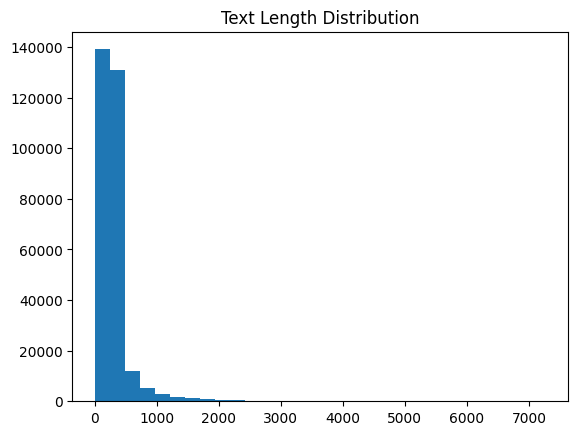

In [47]:
df['text_length'] = df['Review'].apply(len)

plt.hist(df['text_length'], bins=30)
plt.title("Text Length Distribution")
plt.show()

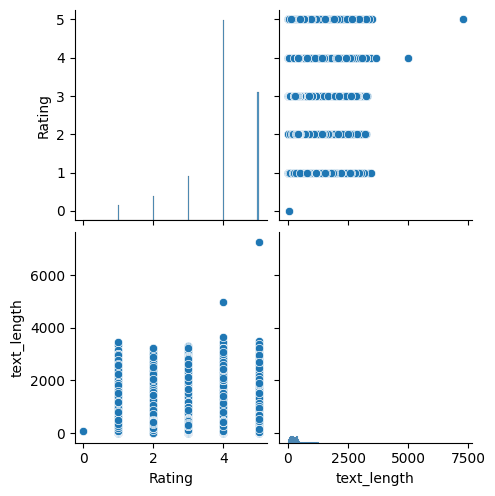

In [48]:
sns.pairplot(df)
plt.show()

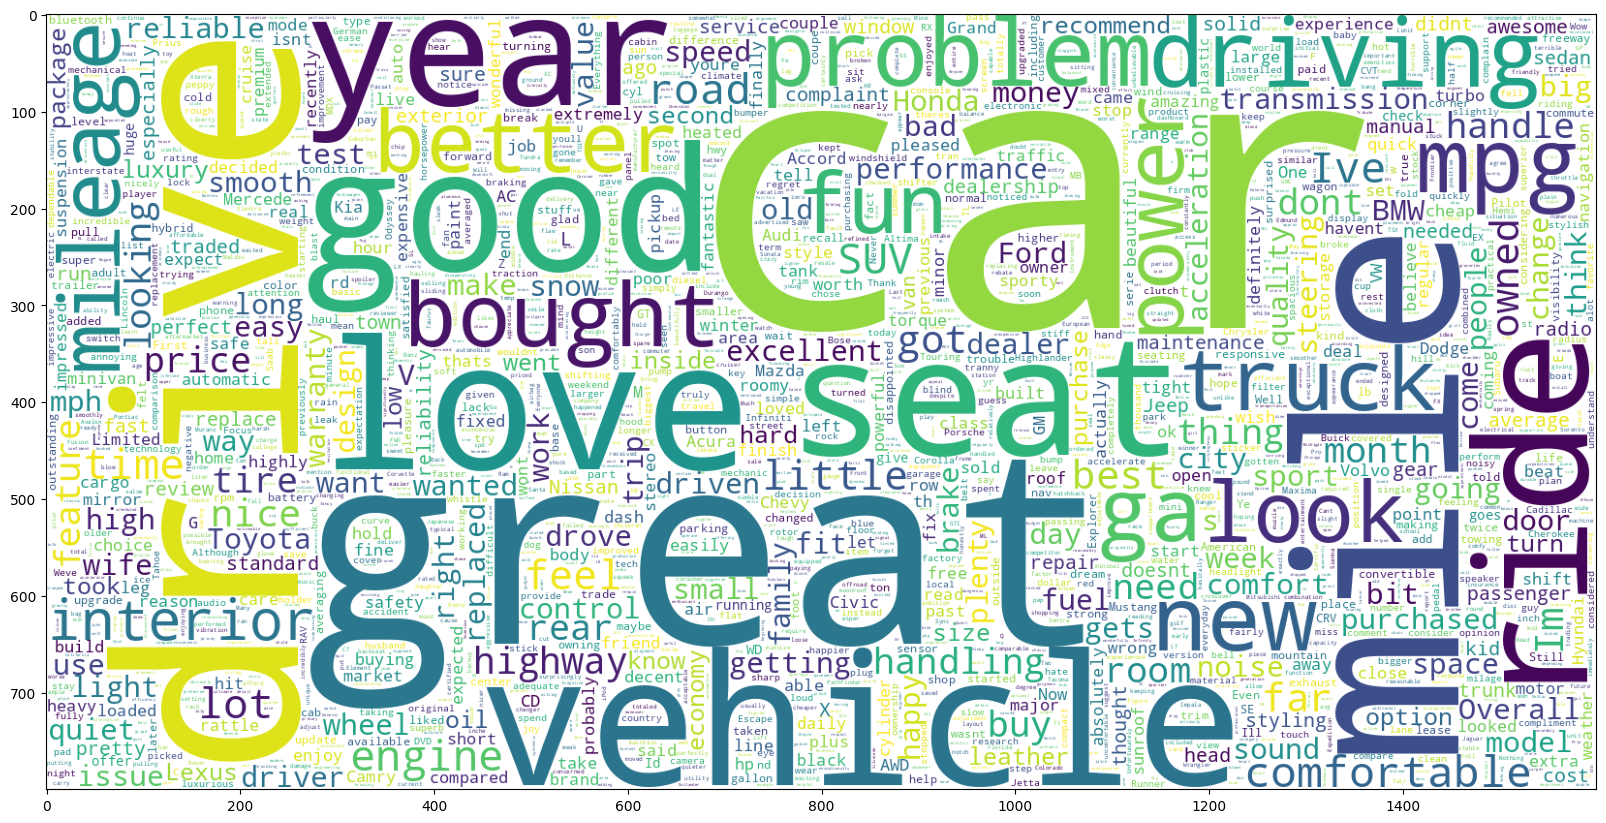

In [49]:
def convert_sentiment(rating):
    if rating <= 3:
        return 0  # Negative
    elif rating == 4:
        return 1  # Neutral
    else:
        return 2  # Positive

df['Sentiment'] = df['Rating'].apply(convert_sentiment)
wordCloud(df.loc[df["Sentiment"] == 1, "Review"],2000)

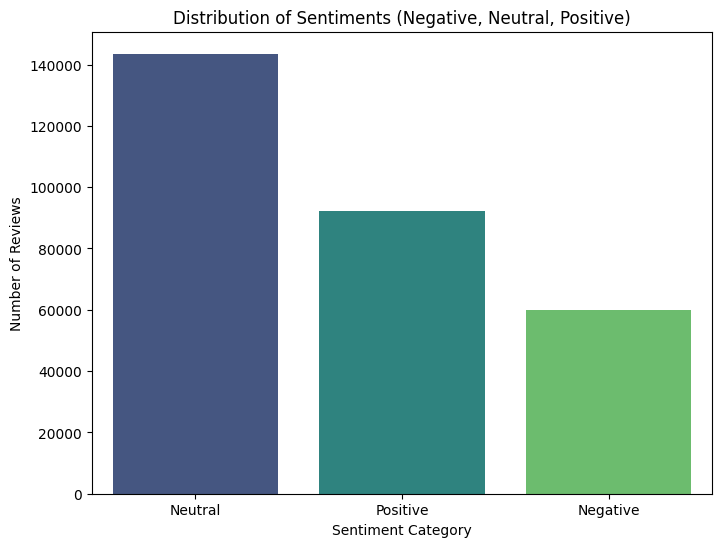

In [50]:
# Get the counts of each sentiment
sentiment_counts = df['Sentiment'].value_counts()

# Map sentiment labels for better readability on the plot
sentiment_labels = {0: 'Negative', 1: 'Neutral', 2: 'Positive'}
sentiment_counts.index = sentiment_counts.index.map(sentiment_labels)

# Create a bar chart
plt.figure(figsize=(8, 6))
sns.barplot(x=sentiment_counts.index, y=sentiment_counts.values, palette='viridis')
plt.title('Distribution of Sentiments (Negative, Neutral, Positive)')
plt.xlabel('Sentiment Category')
plt.ylabel('Number of Reviews')
plt.show()

In [51]:
!pip install imbalanced-learn

In [52]:
from imblearn.over_sampling import SMOTE
from sklearn.feature_extraction.text import TfidfVectorizer

# 1. We first need to convert text to numbers (Vectorization) before SMOTE
tfidf = TfidfVectorizer(max_features=5000)
X_tfidf = tfidf.fit_transform(df['tokenized_Review_stemmed_lemmatized'])
y = df['Sentiment']

# 2. Apply SMOTE to balance the dataset
smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X_tfidf, y)

print(f'Original dataset shape: {y.value_counts().to_dict()}')
print(f'Resampled dataset shape: {y_res.value_counts().to_dict()}')

# 3. New Train-Test Split with balanced data
X_train_bal, X_test_bal, y_train_bal, y_test_bal = train_test_split(
    X_res, y_res, test_size=0.2, random_state=42, stratify=y_res
)

Original dataset shape: {1: 143524, 2: 92078, 0: 60000}
Resampled dataset shape: {2: 143524, 1: 143524, 0: 143524}


In [53]:
# Seperating input feature and label
X = df['tokenized_Review_stemmed_lemmatized']
y = df['Sentiment']


In [54]:
# 6. Train-Test Split
# We use the processed text column 'tokenized_Review_stemmed_lemmatized' as X
X_train, X_test, y_train, y_test = train_test_split(
    df['tokenized_Review_stemmed_lemmatized'],
    df['Sentiment'],
    test_size=0.2,
    random_state=42,
    stratify=df['Sentiment']
)

print(f"Training set size: {len(X_train)}")
print(f"Testing set size: {len(X_test)}")

Training set size: 236481
Testing set size: 59121


In [55]:
def model_evaluation(model, X_train, X_test, y_train, y_test):
    # Train the model
    y_pred = model.predict(X_test)

    # Print the evalution metrics for the dataset

    print(classification_report(y_test, y_pred))

    # compute and plot the Confusion matrix
    cf_matrix = confusion_matrix(y_test, y_pred)
    categories = ['Negative', 'Neutral', 'Positive']
    group_names = ['True Neg', 'False Pos', 'False Neg', 'True Pos']
    group_percentages = ['{0:.2%}'.format(value) for value in cf_matrix.flatten() / np.sum(cf_matrix)]
    labels = [f'{v1}\n{v2}' for v1, v2 in zip(group_names,group_persecentages)]
    labels = np.asarray(labels).reshape(2,2)
    sns.heatmap(cf_matrix, annot = labels, cmap = 'Blues',fmt = '',
                xticklabels = categories, yticklabels = categories)
    plt.xlabel("Predicted values", fontdict = {'size':14}, labelpad = 10)
    plt.ylabel("Actual values" , fontdict = {'size':14}, labelpad = 10)
    plt.title ("Confusion Matrix", fontdict = {'size':18}, pad = 20)


In [57]:
import time  # <-- Add this line
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report

# Model-2 : SVM(Support Vector Machine) using balanced data
SVCmodel = LinearSVC(random_state=42)
start1 = time.time()
SVCmodel.fit(X_train_bal, y_train_bal)
end1 = time.time()
print("Training time: {:.2f}s".format(end1 - start1))

y_pred2 = SVCmodel.predict(X_test_bal)
print("SVM Classification Report:")
print(classification_report(y_test_bal, y_pred2))

Training time: 58.12s
SVM Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.83      0.82     28705
           1       0.60      0.55      0.58     28705
           2       0.63      0.66      0.65     28705

    accuracy                           0.68     86115
   macro avg       0.68      0.68      0.68     86115
weighted avg       0.68      0.68      0.68     86115



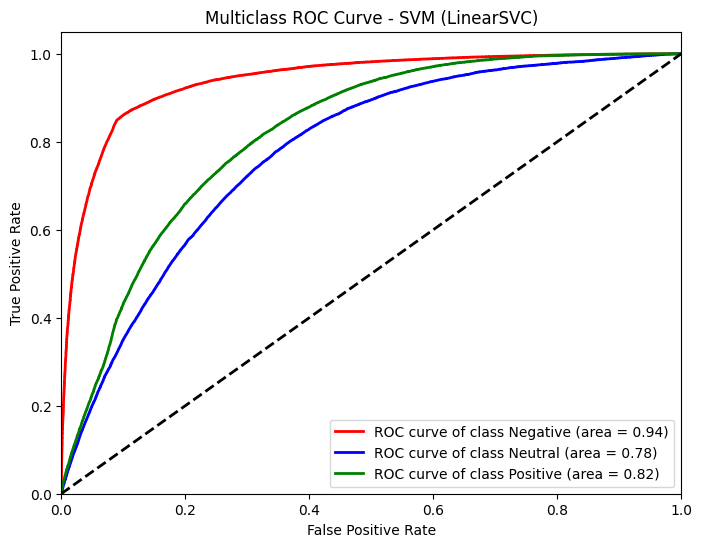

In [58]:
from sklearn.preprocessing import label_binarize

# 1. Binarize labels for the balanced test set
y_test_bin = label_binarize(y_test_bal, classes=[0, 1, 2])
n_classes = y_test_bin.shape[1]

# 2. LinearSVC uses decision_function instead of predict_proba
y_score2 = SVCmodel.decision_function(X_test_bal)

# 3. Compute ROC curve and AUC for each class
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score2[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# 4. Plotting
plt.figure(figsize=(8, 6))
colors = ['red', 'blue', 'green']
labels = ['Negative', 'Neutral', 'Positive']

for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label='ROC curve of class {0} (area = {1:0.2f})'.format(labels[i], roc_auc[i]))

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multiclass ROC Curve - SVM (LinearSVC)')
plt.legend(loc="lower right")
plt.show()